In [52]:
from collections import defaultdict
from tqdm import tqdm

import numpy as np
import math
import statistics as stat
import random

from utils import cross_bin_matching, neighbour_matching, max_weight_matching, PairSwapICI_test, marg_indep_test, GCM_test
from scipy.stats import norm

import matplotlib.pyplot as plt
from matplotlib import ticker, patches

from sklearn.linear_model import LinearRegression
from sklearn.isotonic import IsotonicRegression

from sklearn.isotonic import isotonic_regression as PAVA
from statsmodels.nonparametric.kernel_regression import KernelReg

lblue  = (40/255,103/255,178/255)
sgreen = (46/255,139/255,87/255)
worange = (255/255, 165/255, 70/255)

In [66]:
def IDR(x, y, y_grid=None, y_grid_size=100, is_sorted=True):
    """
    Estimate conditional CDFs F(y | x) under isotonicity in x.
    
    Parameters:
    - x: 1D array-like of covariate values
    - y: 1D array-like of responses
    - y_grid: 1D array-like of y values at which to evaluate the conditional CDF. 
              If None, it uses 100 quantiles of y.
    
    Returns:
    - y_grid: sorted grid of y values
    - x_sorted: sorted values of x
    - F_hat: array of shape (len(y_grid), len(x)) with estimated F(y | x)
    """
    x = np.asarray(x)
    y = np.asarray(y)
    if y_grid is None:
        y_grid = np.quantile(y, np.linspace(0, 1, y_grid_size))
    y_grid = np.sort(np.unique(y_grid))
    
    if not is_sorted:
        o = np.argsort(-x)
        x = x[o]
        y = y[o]
    
    F_hat = np.zeros((len(y_grid), len(x)))
    
    for i, y0 in enumerate(y_grid):
        indicators = 1.*(y <= y0)
        F_hat[i, :] = PAVA(indicators) 
    
    return y_grid, x, F_hat

def sample_from_isotonic_cdf(y_grid, x_sorted, F_hat, x_val, n_samples=1):

    samples = []

    # If outside range, clip to endpoints
    if x_val <= x_sorted[0]:
        F_interp = F_hat[:, 0]
    elif x_val >= x_sorted[-1]:
        F_interp = F_hat[:, -1]
    else:
        # Find where x_val falls between two sorted x's
        idx = np.searchsorted(x_sorted, x_val) - 1
        idx = np.clip(idx, 0, len(x_sorted) - 2)
        x_left, x_right = x_sorted[idx], x_sorted[idx + 1]
        w = (x_val - x_left) / (x_right - x_left)
        # Linear interpolation between the two neighboring CDFs
        F_interp = (1 - w) * F_hat[:, idx] + w * F_hat[:, idx + 1]

    # Sample from the interpolated CDF
    u = np.random.uniform(0, 1, size=n_samples)
    sample_indices = np.searchsorted(F_interp, u, side='right')
    sampled_y = y_grid[np.clip(sample_indices, 0, len(y_grid)-1)]
    samples.append(sampled_y)

    samples = np.array(samples)
    if samples.shape[0] == 1:
        return samples[0]
    return samples

def dCRT_test(X, Y, Z, mu_X, mu_Y, X_grid, Z_sorted, F_XZ, n_sample):

    # Compute residuals
    res_X = X - mu_X(Z)
    res_Y = Y - mu_Y(Z)
    del_xy = res_X * res_Y
    n = len(del_xy)
    
    mean_del = np.mean(del_xy)
    std_del = np.std(del_xy, ddof=1)

    # test_statistic 
    test_stat = (np.sqrt(n) * mean_del) / std_del if std_del != 0 else np.inf

    X_sampled = np.zeros((n, n_sample))  
    
    for i in range(n):
        Y_sampled[i, :] = np.random.normal(0, 1, n_sample)
        X_sampled[i, :] = 
        #X_sampled[i, :] = sample_from_isotonic_cdf(X_grid, Z_sorted, F_XZ, Z[i], n_sample)

    null_test_stats = np.zeros(n_sample)
    for i in range(n_sample):
        res_X_sampled = X_sampled[:,i] - mu_X(Z)
        del_xy_sampled = res_X_sampled * res_Y
    
        mean_del_sampled = np.mean(del_xy_sampled)
        std_del_sampled = np.std(del_xy_sampled, ddof=1)
    
        # test_statistic 
        null_test_stats[i] = (np.sqrt(n) * mean_del_sampled) / std_del_sampled if std_del != 0 else np.inf
            
    # Compute p-value
    return (1 + np.sum(test_stat >= null_test_stats)) / (1 + n_sample)

In [82]:
Y, Z = sim_YZ(n, setting)
# sample splitting: estimate on split 1, run test on split 2
Y1, Y2 = Y[:n//3], Y[n//3:]
Z1, Z2 = Z[:n//3], Z[n//3:]
X = Z/2 + 1 * np.abs(Y) + np.random.normal(0,1, n)
X1, X2 = X[:n//3], X[n//3:]

iso_reg = IsotonicRegression(out_of_bounds='clip')
iso_reg.fit(Z1, X1)
mu_X = lambda Z_input: iso_reg.predict(Z_input)
            
lin_reg = LinearRegression()
lin_reg.fit(Z1.reshape(-1, 1), Y1)
mu_Y = lambda Z_input: lin_reg.predict(Z_input.reshape(-1, 1))

X_grid, Z1_sorted, F_XZ = IDR(Z1,X1, is_sorted=False)
print(dCRT_test(X2, Y2, Z2, mu_X, mu_Y, X_grid, Z1_sorted, F_XZ, 100))
print(n)

0.009900990099009901
100


## Part 1: Type I error analysis

In [40]:
def effect_on_validity(nrep, gamma_seq, n):
    """
    Simulates the effect of varying monotonicity strength on the conservatism of the PairSwap-ICI test.

    This function generates data under two settings, creates matchings using 
    neighbour matching and cross-bin matching, and computes p-values for each 
    combination of gamma (monotonicity strength), setting, and matching method.

    Parameters:
    nrep (int): number of repetitions.
    gamma_seq (array-like): monotonicity-strength values.
    n (int): sample size.

    Returns:
        dict: A nested dictionary storing computed p-values for different settings, 
              gamma values, and matching methods.
    """
    # Initialize p-value storage: with structure [setting][matching][gamma]
    pvalues = defaultdict(lambda: defaultdict(lambda: np.zeros(nrep)))
    
    # Simulation loop
    for l in tqdm(range(nrep), desc="Computing p values"):
        # Generate independent standard normal variables Z and Y
        Z = np.random.normal(0, 1, n)
        Y = np.random.normal(0, 1, n)
        K = int(np.floor(n ** (2 / 3)))  # Number of bins for cross-bin matching

        Y1, Y2 = Y[:n//3], Y[n//3:]
        Z1, Z2 = Z[:n//3], Z[n//3:]
                
        
        # # Compute matching based on (Y,Z)
        # matchings = {
        #     'nbhd': neighbour_matching(Y, Z),
        #     'cb': cross_bin_matching(Y, Z, K),
        # }

        # Iterate over gamma values
        for gamma in gamma_seq:
            # Iterate over settings: linear and non-linear dependence
            for setting in range(2):
                if setting == 0:
                    mu = gamma * Z  # Linear dependence
                    
                elif setting == 1:
                    mu = norm.cdf(gamma * Z)  # Non-linear dependence

                # Generate X
                X = mu + np.random.standard_t(3, n)
                X1, X2 = X[:n//3], X[n//3:]

                # Non-parametric regression on first split
                kr = KernelReg(endog=X1, exog=np.column_stack((Y1, Z1)), var_type='cc')
                E_X_given_YZ, _ = kr.fit(np.column_stack((Y2, Z2)))
                    
                m = len(Z2)
                E = np.zeros((m, m))
                for i in range(m):
                    for j in range(m):
                        if Z2[i] < Z2[j]:
                            E[i, j] = E_X_given_YZ[i] - E_X_given_YZ[j]
                    
                V = np.ones((m, m))
                M = max_weight_matching(E, V) 
                Del_W = np.array([np.max(E[i,j],0) for (i, j) in M])
                
                pvalues[(setting, 'pairswap')][gamma][l] = PairSwapICI_test(X2, Y2, M, Del_W)
            
                # --- GCM Test ---
                iso_reg = IsotonicRegression(out_of_bounds='clip')
                iso_reg.fit(Z1, X1)
                mu_X = lambda Z_input: iso_reg.predict(Z_input)
            
                lin_reg = LinearRegression()
                lin_reg.fit(Z1.reshape(-1, 1), Y1)
                mu_Y = lambda Z_input: lin_reg.predict(Z_input.reshape(-1, 1))
            
                pvalues[(setting, 'gcm')][gamma][l] = GCM_test(X2, Y2, Z2, mu_X, mu_Y)


    return pvalues

# === simulation results ===
nrep = 2000; n = 100
gamma_seq = 10 ** np.linspace(-1, 1, 7)  # Sequence of gamma values in [.1, 1, 10]

results = effect_on_validity(nrep, gamma_seq, n)

Computing p values:   1%|                   | 12/2000 [01:08<3:19:22,  6.02s/it]/opt/anaconda3/lib/python3.11/site-packages/numpy/linalg/linalg.py:2027: RuntimeWarning: overflow encountered in divide
  s = divide(1, s, where=large, out=s)
Computing p values:  16%|██▋             | 329/2000 [1:19:16<2:40:47,  5.77s/it]/opt/anaconda3/lib/python3.11/site-packages/numpy/linalg/linalg.py:2027: RuntimeWarning: overflow encountered in divide
  s = divide(1, s, where=large, out=s)
Computing p values:  17%|██▊             | 348/2000 [1:21:03<2:25:49,  5.30s/it]/opt/anaconda3/lib/python3.11/site-packages/numpy/linalg/linalg.py:2027: RuntimeWarning: overflow encountered in divide
  s = divide(1, s, where=large, out=s)
/opt/anaconda3/lib/python3.11/site-packages/networkx/algorithms/matching.py:504: RuntimeWarning: invalid value encountered in scalar subtract
  return dualvar[v] + dualvar[w] - 2 * G[v][w].get(weight, 1)
/opt/anaconda3/lib/python3.11/site-packages/networkx/algorithms/matching.py:104

In [41]:
print(results[(0,'pairswap')][gamma_seq[2]])
[np.mean(results[(0, 'gcm')][gamma] < alpha) for gamma in gamma_seq]

[0.87012987 0.86313686 0.47552448 ... 0.11788212 0.000999   0.2037962 ]


[0.135, 0.1195, 0.1225, 0.117, 0.1115, 0.1225, 0.1205]

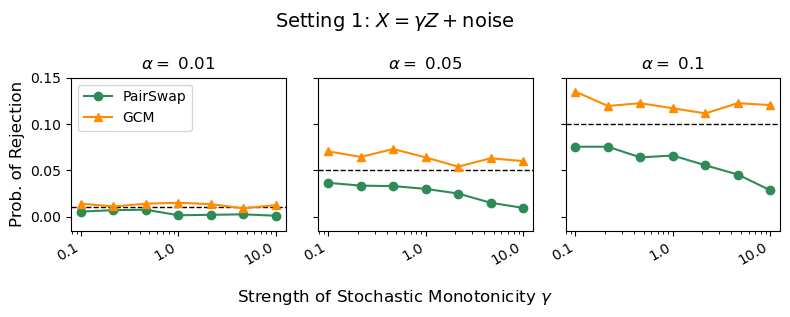

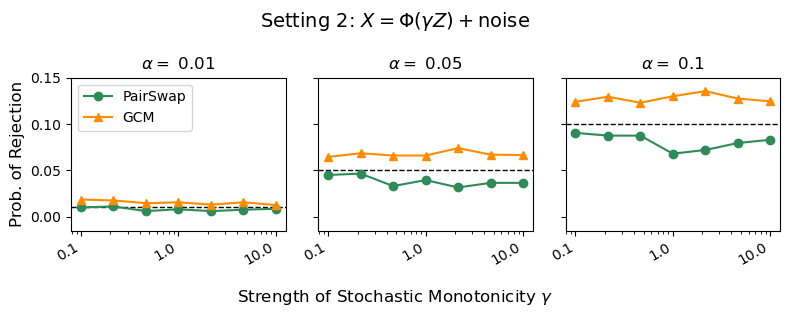

In [43]:
# Parameters
alphas = [0.01, 0.05, 0.1]  # Significance levels
col_titles = [r'$\alpha=$ {}'.format(a) for a in alphas]  # Column titles
titles = [
    r'$X = \gamma Z + \text{noise}$',
    r'$X = \Phi(\gamma Z) + \text{noise}$'
]  # Titles for the two settings
methods = [
        ('pairswap', 'PairSwap', 'seagreen', 'o'),
        ('gcm', 'GCM', 'darkorange', '^')
    ]


def plot_validity_curves(results, gamma_seq, nrep, settings_titles, alphas, methods):
    """
    Plots validity curves against monotonicity strength for different settings and significance levels.

    Args:
        results (dict): Nested dictionary with p-values for different settings, matchings, and gammas.
        gamma_seq (list): Sequence of gamma values tested.
        nrep (int): Number of repetitions in the simulation.
        settings_titles (list): Titles for the settings being tested.
        alphas (list): List of significance levels.
        methods (list): List of tuples containing method key, matching label, color, and marker.

    Outputs:
        Saves and displays plots for each setting.
    """
    for setting, title in enumerate(settings_titles):
        fig, axes = plt.subplots(nrows=1, ncols=len(alphas), figsize=(8, 3.3), sharex=True, sharey=True)
        axes[0].set_ylim([-0.015, 0.15])

        for col, alpha in enumerate(alphas):
            axes[col].set_title(col_titles[col], fontsize=12)
            axes[col].axhline(y=alpha, color='black', linestyle='--', linewidth=1)
            
            for key, matching, color, marker in methods:
                rejection_probs = [
                    np.mean(results[(setting, key)][gamma] < alpha) for gamma in gamma_seq # compute type-I error
                ]
                axes[col].plot(
                    gamma_seq, rejection_probs, marker=marker, linestyle='solid', color=color, label=matching
                )

        for ax in axes:
            ax.set_xscale('log')
            ax.set_xticks([0.1, 1, 10])  # Only three labels
            ax.set_xticklabels([0.1, 1, 10], rotation=30, horizontalalignment='right')
            ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())

        axes[0].legend(loc='upper left', fontsize=10)

        axes[0].set_ylabel('Prob. of Rejection', fontsize=12)
        fig.supxlabel('Strength of Stochastic Monotonicity $\\gamma$', y=0.03, fontsize=12)
        fig.suptitle(f'Setting {setting + 1}: {title}', y=0.93, fontsize=14)

        plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout
        fig.savefig(f'figures/validity_curve_log_nrep={nrep}_setting={setting + 1}.pdf', bbox_inches='tight')
        plt.show()

# === visualize our results ===
plot_validity_curves(results, gamma_seq, nrep, titles, alphas, methods)


In [2]:
def sim_YZ(n, setting):
    """ Simulates paired samples (Y, Z) with specified correlation structure. """
    
    if setting == 1:
        rho = 0
    elif setting == 2:
        rho = 0.5
    elif setting == 3:
        rho = -0.5
    else:
        raise ValueError("Invalid setting. Choose from {1, 2, 3}.")

    # Generate multivariate normal samples
    cov = (1 - rho) * np.eye(2) + rho * np.ones((2, 2))
    Y, Z = np.random.multivariate_normal([0, 0], cov, size=n).T

    return Y, Z

In [9]:
def plot_power_vs_n_by_beta(power_results, nseq, nrep):
    """
    Plots power curves vs sample size for beta_setting ∈ {0,1},
    comparing PairSwap and GCM tests.

    Args:
        power_results (list): List of one dictionary (only rho=0 setting)
        nseq (array): Sample sizes
        nrep (int): Number of repetitions (used for labeling)
    """
    methods = [
        ('pairswap', 'PairSwap', 'seagreen', 'o'),
        ('gcm', 'GCM', 'darkorange', '^'),
        ('dCRT', 'dCRT', lblue, '+')
    ]
    beta_titles = [
        r'$\beta_n = 0$',
        r'$\beta_n = 1$'
    ]

    fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

    power_dict = power_results[0]  # Only one rho setting assumed

    for beta_setting in [0, 1]:
        ax = axes[beta_setting]
        ax.axhline(0.1, color='gray', linestyle='--', linewidth=1, label='Significance level')

        for key, label, color, marker in methods:
            power_vals = power_dict.get((beta_setting, key), {})
            yvals = [power_vals.get(n, 0) for n in nseq]
            ax.plot(nseq, yvals, marker=marker, linestyle='-', color=color, label=label)

        ax.set_title(beta_titles[beta_setting], fontsize=11)
        ax.set_xlabel('Sample size $n$', fontsize=10)
        ax.set_xticks(nseq)
        ax.set_ylim([-0.05, 1.05])
        ax.grid(False)

    axes[0].set_ylabel('Power (prob. of rejection)', fontsize=10)
    axes[0].legend(fontsize=8, loc='upper right')

    plt.suptitle(r'Power vs Sample Size ($\rho_{YZ} = 0$)', fontsize=12)
    plt.tight_layout()
    plt.subplots_adjust(top=0.83)
    plt.savefig(f'figures/power-beta-panels-nrep={nrep}.pdf', bbox_inches='tight')
    plt.show()


## Part 2: power analysis: GCM is good

In [11]:
# --- simulation framework for the power calculation ---

nrep = 100  # Number of repetitions for simulations
alpha = 0.1   # Significance level
nseq = np.array([50, 100, 150, 200, 250, 300])  # Sequence of sample sizes

def power_analysis_sim(setting):
    """
    Performs a power analysis simulation to evaluate the performance of different matching methods.

    Args:
        setting (int): Specifies the correlation structure for the Y and Z variables.
                       - 1: Independent variables.
                       - 2: Positively correlated variables.
                       - 3: Negatively correlated variables.

    Returns:
        power (dict): A nested dictionary where:
                - Keys are tuples (beta_setting, method).
                - Values are dictionaries where keys are sample sizes `n` and 
                                                values are the estimated power (proportion of rejections).

    """
    # Initialize storage for p-values and power
    pvalues = defaultdict(lambda: defaultdict(lambda: np.zeros(nrep)))
    power = defaultdict(lambda: defaultdict(float))
              

    for n in nseq:
        for l in tqdm(range(nrep), desc=f"Processing sample size {n}, Setting {setting}"):
            
            # Generate data of Y,Z
            Y, Z = sim_YZ(n, setting)

            # sample splitting: estimate on split 1, run test on split 2
            Y1, Y2 = Y[:n//3], Y[n//3:]
            Z1, Z2 = Z[:n//3], Z[n//3:]
            
            for beta_setting in [0, 1]:

                if beta_setting ==0:
                    beta = 0
                else: beta = 1
                
                # Generate X
                X = Z/2 + beta * Y + np.random.normal(0,1, n)
                X1, X2 = X[:n//3], X[n//3:]
            
                # Non-parametric regression on first split
                kr = KernelReg(endog=X1, exog=np.column_stack((Y1, Z1)), var_type='cc')
                E_X_given_YZ, _ = kr.fit(np.column_stack((Y2, Z2)))
            
                m = len(Z2)
                E = np.zeros((m, m))
                for i in range(m):
                    for j in range(m):
                        if Z2[i] < Z2[j]:
                            E[i, j] = E_X_given_YZ[i] - E_X_given_YZ[j]
            
                V = np.ones((m, m))
                M = max_weight_matching(E, V) 
                Del_W = np.array([np.max(E[i,j],0) for (i, j) in M])
                
                pvalues[(beta_setting, 'pairswap')][n][l] = PairSwapICI_test(X2, Y2, M, Del_W)
            
                # --- GCM Test ---
                iso_reg = IsotonicRegression(out_of_bounds='clip')
                iso_reg.fit(Z1, X1)
                mu_X = lambda Z_input: iso_reg.predict(Z_input)
            
                lin_reg = LinearRegression()
                lin_reg.fit(Z1.reshape(-1, 1), Y1)
                mu_Y = lambda Z_input: lin_reg.predict(Z_input.reshape(-1, 1))
            
                pvalues[(beta_setting, 'gcm')][n][l] = GCM_test(X2, Y2, Z2, mu_X, mu_Y)


        # Compute power for each combination of (gamma, label)
        for key in pvalues:
            power[key][n] = np.mean(pvalues[key][n] < alpha)

    return pvalues, power

# === power calculation for the three different settings ===
power_results = []
for setting in [1]:
    _, power = power_analysis_sim(setting)
    power_results.append(power)

Processing sample size 50, Setting 1:  59%|██▎ | 59/100 [00:19<00:12,  3.37it/s]/opt/anaconda3/lib/python3.11/site-packages/numpy/linalg/linalg.py:2027: RuntimeWarning: overflow encountered in divide
  s = divide(1, s, where=large, out=s)
/opt/anaconda3/lib/python3.11/site-packages/numpy/linalg/linalg.py:2030: RuntimeWarning: invalid value encountered in matmul
  res = matmul(transpose(vt), multiply(s[..., newaxis], transpose(u)))
Processing sample size 300, Setting 1: 100%|██| 100/100 [08:52<00:00,  5.32s/it]


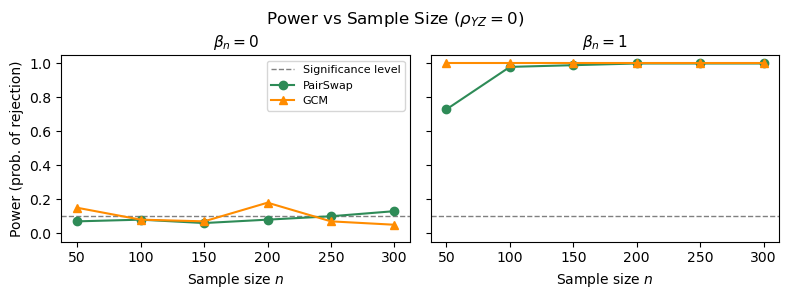

In [12]:
plot_power_vs_n_by_beta(power_results, nseq, nrep)

## Part 2: power analysis: GCM is bad

In [3]:
# --- simulation framework for the power calculation ---

nrep = 100  # Number of repetitions for simulations
alpha = 0.1   # Significance level
nseq = np.array([50, 100, 150, 200, 250, 300])  # Sequence of sample sizes

def power_analysis_sim(setting):
    """
    Performs a power analysis simulation to evaluate the performance of different matching methods.

    Args:
        setting (int): Specifies the correlation structure for the Y and Z variables.
                       - 1: Independent variables.
                       - 2: Positively correlated variables.
                       - 3: Negatively correlated variables.

    Returns:
        power (dict): A nested dictionary where:
                - Keys are tuples (beta_setting, method).
                - Values are dictionaries where keys are sample sizes `n` and 
                                                values are the estimated power (proportion of rejections).

    """
    # Initialize storage for p-values and power
    pvalues = defaultdict(lambda: defaultdict(lambda: np.zeros(nrep)))
    power = defaultdict(lambda: defaultdict(float))
              

    for n in nseq:
        for l in tqdm(range(nrep), desc=f"Processing sample size {n}, Setting {setting}"):
            
            # Generate data of Y,Z
            Y, Z = sim_YZ(n, setting)

            # sample splitting: estimate on split 1, run test on split 2
            Y1, Y2 = Y[:n//3], Y[n//3:]
            Z1, Z2 = Z[:n//3], Z[n//3:]
            
            for beta_setting in [0, 1]:

                if beta_setting ==0:
                    beta = 0
                else: beta = 1
                
                # Generate X
                X = Z/2 + beta * np.abs(Y) + np.random.normal(0,1, n)
                X1, X2 = X[:n//3], X[n//3:]
            
                # Non-parametric regression on first split
                kr = KernelReg(endog=X1, exog=np.column_stack((Y1, Z1)), var_type='cc')
                E_X_given_YZ, _ = kr.fit(np.column_stack((Y2, Z2)))
            
                m = len(Z2)
                E = np.zeros((m, m))
                for i in range(m):
                    for j in range(m):
                        if Z2[i] < Z2[j]:
                            E[i, j] = E_X_given_YZ[i] - E_X_given_YZ[j]
            
                V = np.ones((m, m))
                M = max_weight_matching(E, V) 
                Del_W = np.array([np.max(E[i,j],0) for (i, j) in M])
                
                pvalues[(beta_setting, 'pairswap')][n][l] = PairSwapICI_test(X2, Y2, M, Del_W)
            
                # --- GCM Test ---
                iso_reg = IsotonicRegression(out_of_bounds='clip')
                iso_reg.fit(Z1, X1)
                mu_X = lambda Z_input: iso_reg.predict(Z_input)
            
                lin_reg = LinearRegression()
                lin_reg.fit(Z1.reshape(-1, 1), Y1)
                mu_Y = lambda Z_input: lin_reg.predict(Z_input.reshape(-1, 1))
            
                pvalues[(beta_setting, 'gcm')][n][l] = GCM_test(X2, Y2, Z2, mu_X, mu_Y)


        # Compute power for each combination of (gamma, label)
        for key in pvalues:
            power[key][n] = np.mean(pvalues[key][n] < alpha)

    return pvalues, power

# === power calculation for the three different settings ===
power_results = []
for setting in [1]:
    _, power = power_analysis_sim(setting)
    power_results.append(power)

Processing sample size 50, Setting 1:  62%|██▍ | 62/100 [00:21<00:11,  3.29it/s]/opt/anaconda3/lib/python3.11/site-packages/numpy/linalg/linalg.py:2027: RuntimeWarning: overflow encountered in divide
  s = divide(1, s, where=large, out=s)
/opt/anaconda3/lib/python3.11/site-packages/numpy/linalg/linalg.py:2030: RuntimeWarning: invalid value encountered in matmul
  res = matmul(transpose(vt), multiply(s[..., newaxis], transpose(u)))
Processing sample size 300, Setting 1: 100%|██| 100/100 [09:05<00:00,  5.46s/it]

defaultdict(<function power_analysis_sim.<locals>.<lambda> at 0x1726dd9e0>, {(0, 'pairswap'): defaultdict(<class 'float'>, {50: 0.05, 100: 0.1, 150: 0.12, 200: 0.05, 250: 0.08, 300: 0.06}), (0, 'gcm'): defaultdict(<class 'float'>, {50: 0.15, 100: 0.13, 150: 0.06, 200: 0.12, 250: 0.09, 300: 0.09}), (1, 'pairswap'): defaultdict(<class 'float'>, {50: 0.16, 100: 0.53, 150: 0.85, 200: 0.97, 250: 0.97, 300: 0.95}), (1, 'gcm'): defaultdict(<class 'float'>, {50: 0.22, 100: 0.13, 150: 0.13, 200: 0.1, 250: 0.15, 300: 0.05})})


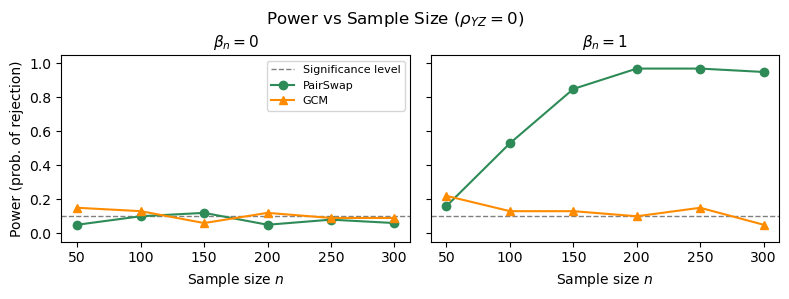

In [10]:
plot_power_vs_n_by_beta(power_results, nseq, nrep)

## with DCRT

In [71]:
#--- simulation framework for the power calculation ---

nrep = 100  # Number of repetitions for simulations
alpha = 0.1   # Significance level
nseq = np.array([50, 100, 200, 300])  # Sequence of sample sizes

def power_analysis_sim(setting):
    """
    Performs a power analysis simulation to evaluate the performance of different matching methods.

    Args:
        setting (int): Specifies the correlation structure for the Y and Z variables.
                       - 1: Independent variables.
                       - 2: Positively correlated variables.
                       - 3: Negatively correlated variables.

    Returns:
        power (dict): A nested dictionary where:
                - Keys are tuples (beta_setting, method).
                - Values are dictionaries where keys are sample sizes `n` and 
                                                values are the estimated power (proportion of rejections).

    """
    # Initialize storage for p-values and power
    pvalues = defaultdict(lambda: defaultdict(lambda: np.zeros(nrep)))
    power = defaultdict(lambda: defaultdict(float))
              

    for n in nseq:
        for l in tqdm(range(nrep), desc=f"Processing sample size {n}, Setting {setting}"):
            
            # Generate data of Y,Z
            Y, Z = sim_YZ(n, setting)

            # sample splitting: estimate on split 1, run test on split 2
            Y1, Y2 = Y[:n//3], Y[n//3:]
            Z1, Z2 = Z[:n//3], Z[n//3:]
            
            for beta_setting in [0, 1]:

                if beta_setting ==0:
                    beta = 0
                else: beta = 1
                
                # Generate X
                X = Z/2 + beta * np.abs(Y) + np.random.normal(0,1, n)
                X1, X2 = X[:n//3], X[n//3:]
            
                # Non-parametric regression on first split
                kr = KernelReg(endog=X1, exog=np.column_stack((Y1, Z1)), var_type='cc')
                E_X_given_YZ, _ = kr.fit(np.column_stack((Y2, Z2)))
            
                m = len(Z2)
                E = np.zeros((m, m))
                for i in range(m):
                    for j in range(m):
                        if Z2[i] < Z2[j]:
                            E[i, j] = E_X_given_YZ[i] - E_X_given_YZ[j]
            
                V = np.ones((m, m))
                M = max_weight_matching(E, V) 
                Del_W = np.array([np.max(E[i,j],0) for (i, j) in M])
                
                pvalues[(beta_setting, 'pairswap')][n][l] = PairSwapICI_test(X2, Y2, M, Del_W)
            
                # --- GCM Test ---
                iso_reg = IsotonicRegression(out_of_bounds='clip')
                iso_reg.fit(Z1, X1)
                mu_X = lambda Z_input: iso_reg.predict(Z_input)
            
                lin_reg = LinearRegression()
                lin_reg.fit(Z1.reshape(-1, 1), Y1)
                mu_Y = lambda Z_input: lin_reg.predict(Z_input.reshape(-1, 1))
            
                pvalues[(beta_setting, 'gcm')][n][l] = GCM_test(X2, Y2, Z2, mu_X, mu_Y)

                X_grid, Z1_sorted, F_XZ = IDR(Z1,X1, is_sorted=False)
                pvalues[(beta_setting, 'dCRT')][n][l] = dCRT_test(X2, Y2, Z2, mu_X, mu_Y, X_grid, Z1_sorted, F_XZ, 100)


        # Compute power for each combination of (gamma, label)
        for key in pvalues:
            power[key][n] = np.mean(pvalues[key][n] < alpha)

    return pvalues, power

# === power calculation for the three different settings ===
power_results = []
for setting in [1]:
    _, power = power_analysis_sim(setting)
    power_results.append(power)

Processing sample size 300, Setting 1: 100%|██| 100/100 [09:02<00:00,  5.43s/it]


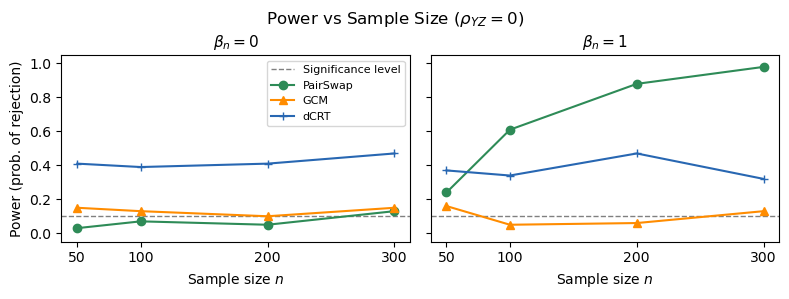

In [72]:
def plot_power_vs_n_by_beta(power_results, nseq, nrep):
    """
    Plots power curves vs sample size for beta_setting ∈ {0,1},
    comparing PairSwap and GCM tests.

    Args:
        power_results (list): List of one dictionary (only rho=0 setting)
        nseq (array): Sample sizes
        nrep (int): Number of repetitions (used for labeling)
    """
    methods = [
        ('pairswap', 'PairSwap', 'seagreen', 'o'),
        ('gcm', 'GCM', 'darkorange', '^'),
        ('dCRT', 'dCRT', lblue, '+')
    ]
    beta_titles = [
        r'$\beta_n = 0$',
        r'$\beta_n = 1$'
    ]

    fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

    power_dict = power_results[0]  # Only one rho setting assumed

    for beta_setting in [0, 1]:
        ax = axes[beta_setting]
        ax.axhline(0.1, color='gray', linestyle='--', linewidth=1, label='Significance level')

        for key, label, color, marker in methods:
            power_vals = power_dict.get((beta_setting, key), {})
            yvals = [power_vals.get(n, 0) for n in nseq]
            ax.plot(nseq, yvals, marker=marker, linestyle='-', color=color, label=label)

        ax.set_title(beta_titles[beta_setting], fontsize=11)
        ax.set_xlabel('Sample size $n$', fontsize=10)
        ax.set_xticks(nseq)
        ax.set_ylim([-0.05, 1.05])
        ax.grid(False)

    axes[0].set_ylabel('Power (prob. of rejection)', fontsize=10)
    axes[0].legend(fontsize=8, loc='upper right')

    plt.suptitle(r'Power vs Sample Size ($\rho_{YZ} = 0$)', fontsize=12)
    plt.tight_layout()
    plt.subplots_adjust(top=0.83)
    plt.savefig(f'figures/power-beta-panels-nrep={nrep}.pdf', bbox_inches='tight')
    plt.show()


plot_power_vs_n_by_beta(power_results, nseq, nrep)